This notebook produces Figure 7, which loads in the Cropland data layer (CDL) data and plots it, and Figures 8-12, which plot the five focus areas (A-E) with each coherence method, the difference between them, and the CDL for each zoomed-in area.
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel.
***

In [1]:
#import necessary packages
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from collections import defaultdict
from matplotlib.colors import ListedColormap
%matplotlib  widget

In [2]:
# Define the focus areas to outline them in the CDL map figure. 
# format is [x_topleft, y_topleft, x_botright, y_botright]
imperial_road = [6820, 100, 7520, 450]   
transect_roads = [4500, 650, 6600, 1000]     
ElCentro_airport = [4575, 980, 5275,1265]    
pools = [7700,300, 8400, 650]     
imperial_airport = [6600,800,7300,1075]  

In [3]:
# define dimensions of the full resolution image/area
dx= 9000; dy=1575
# this is the aspect ratio for plotting that maintains the geographic aspect ratio for visual similarity 
# I used Google Earth to measure the height and width of the ROI in km, this can be updated for other ROIs in a similar way.
aspect_rat = (21.8/dy) / (34.44/dx)

In [4]:
# Load the cropped CDL (this has been converted to radar coordinates)
cdl_path = 'CDL_2023_cropped.tif'
ds = gdal.Open(cdl_path)
cdl_2023 = ds.ReadAsArray()

In [5]:
# how many crop types are actually present here? 
unique_vals = np.unique(cdl_2023)
print(unique_vals)
print('How many unique crop/surface types are present here? \n'+str(len(unique_vals)))

[  0   1   2   4  12  22  24  27  28  31  36  37  41  43  44  49  57  59
  61  69  71  72  75 111 121 122 123 124 131 152 176 190 195 206 208 209
 211 213 214 216 219 225 227 231 243 244]
How many unique crop/surface types are present here? 
46


In [6]:
# load in the csv that's the key to these numbers 
cdl_key_path = 'land_cover_categories.csv'

# See how many values exist in this tif of the 255 possible ones. 
print('Crop code, Num pixels')
for i in range(len(unique_vals)):
    count = np.count_nonzero(cdl_2023==unique_vals[i])
    print(unique_vals[i],'\t',count)

Crop code, Num pixels
0 	 45657
1 	 29665
2 	 366
4 	 351
12 	 30232
22 	 113499
24 	 19
27 	 776
28 	 195850
31 	 11699
36 	 1990962
37 	 1767176
41 	 260316
43 	 68773
44 	 15299
49 	 113256
57 	 15197
59 	 95479
61 	 233579
69 	 641
71 	 73322
72 	 12511
75 	 45
111 	 54125
121 	 302034
122 	 589179
123 	 419171
124 	 121427
131 	 5346478
152 	 1324474
176 	 73383
190 	 69454
195 	 43932
206 	 250614
208 	 261
209 	 41780
211 	 29594
213 	 201
214 	 146898
216 	 405
219 	 88753
225 	 21
227 	 183761
231 	 18
243 	 11544
244 	 2823


In [7]:
# Count unique values
values, counts = np.unique(cdl_2023, return_counts=True)
# Select values (crop types) with at least 1000 pixels
keep_values = values[counts >= 1000]

# wherever a classification exists that had too few pixels, make it a 0 which is considered "background"
masked_cdl = np.where(np.isin(cdl_2023, keep_values), cdl_2023, 0)

In [8]:
new_unique_vals = np.unique(masked_cdl)
print(new_unique_vals)
print('How many unique crop/surface types are present here with at least 100 pixels? \n'+str(len(new_unique_vals)))
# this is much more manageable.

[  0   1  12  22  28  31  36  37  41  43  44  49  57  59  61  71  72 111
 121 122 123 124 131 152 176 190 195 206 209 211 214 219 227 243 244]
How many unique crop/surface types are present here with at least 100 pixels? 
35


In [9]:
# this is traditionally used for CDL
# found here: https://developers.google.com/earth-engine/datasets/catalog/USDA_NASS_CDL#bands
cdl_hex = {
    0:   "#000000",  # Background
    1:   "#ffd400",  # Corn
    12:  "#e0a60f",  # Sweet Corn
    22:  "#8a6453",  # Durum Wheat
    28:  "#a15889",  # Oats
    31:  "#d1ff00",  # Canola
    36:  "#ffa8e3",  # Alfalfa
    37:  "#a5f58d",  # Other Hay/Non-Alfalfa
    41:  "#a900e6",  # Sugarbeets
    43:  "#732600",  # Potatoes
    44:  "#00af4d",  # Other Crops
    49:  "#ffcc66",  # Onions
    57:  "#80d4ff",  # Herbs
    59:  "#b2ffde",  # Sod/Grass Seed
    61:  "#bfbf7a",  # Fallow/Idle Cropland
    71:  "#b39c70",  # Other Tree Crops
    72:  "#ffff80",  # Citrus
    111: "#4d70a3",  # Open Water
    121: "#9c9c9c",  # Developed / Open Space
    122: "#9c9c9c",  # Developed / Low Intensity
    123: "#9c9c9c",  # Developed / Medium Intensity
    124: "#9c9c9c",  # Developed / High Intensity
    131: "#ccbfa3",  # Barren
    152: "#c7d79e",  # Shrubland
    176: "#e9ffbe",  # Grass/Pasture
    190: "#80b3b3",  # Woody Wetlands
    195: "#80b3b3",  # Herbaceous Wetlands
    206: "#ff6666",  # Carrots
    209: "#ff6666",  # Cantaloupes
    211: "#344a34",  # Olives
    214: "#ff6666",  # Broccoli
    219: "#ff6666",  # Greens
    227: "#ff6666",  # Lettuce
    243: "#ff6666",  # Cabbage
    244: "#ff6666",  # Cauliflower
}

# index only the crops I want to plot 
unique_classes = np.unique(cdl_2023)
classes_to_plot = [c for c in unique_classes if c in cdl_hex]
class_to_index = {cls: i for i, cls in enumerate(classes_to_plot)}

# remap the masked CDL with fewer crop types 
remapped = np.full(masked_cdl.shape, np.nan)
for cls, idx in class_to_index.items():
    remapped[masked_cdl == cls] = idx

# make the right colors match the right crop type since we have fewer than the original CDL.
color_list = [cdl_hex[cls] for cls in classes_to_plot]
usda_cmap_2 = mcolors.ListedColormap(color_list)

In [10]:
# Load the key to each crop code.
key = pd.read_csv(cdl_key_path)

# Make sure the columns are correct
# CSV should have: 'value/code', 'crop' (adjust names if different)
print(key.columns)

# Create dictionary: value -> crop name. Categorization Code, Land Cover
# Convert to dictionary: value → crop name
key["Categorization Code"] = key["Categorization Code"].astype(int)
value_to_crop = dict(zip(key["Categorization Code"], key["Land Cover"]))

# Filter labels to only the retained values
filtered_labels = {v: value_to_crop[v] for v in keep_values if v in value_to_crop}

Index(['Categorization Code', 'Land Cover'], dtype='object')


In [11]:
# Make a few custom categories 
# Group classes by identical color
color_groups = defaultdict(list)

for val in keep_values:
    if val in cdl_hex and val in filtered_labels:
        color = cdl_hex[val]
        label = filtered_labels[val]
        color_groups[color].append(label)
custom_group_names = {
    "#9c9c9c": "Developed",
    "#80b3b3": "Wetlands",
    "#ff6666": "Vegetable Crops",
}
legend_handles = []
for color, labels in color_groups.items():
    # use custom label if defined
    if color in custom_group_names:
        legend_label = custom_group_names[color]
    else:
        # otherwise use actual crop names
        legend_label = ", ".join(labels)
    patch = patches.Patch(
        color=color,
        label=legend_label
    )
    legend_handles.append(patch)

In [12]:
# make patches of focus areas to add to figure.
imp_roads_rect = patches.Rectangle((imperial_road[0], imperial_road[3]), imperial_road[2]- imperial_road[0], imperial_road[1]- imperial_road[3], linewidth=2, edgecolor='k', facecolor = 'None', alpha=0.5) #imperial_road
tsct_roads_rect = patches.Rectangle((transect_roads[0], transect_roads[3]), transect_roads[2]- transect_roads[0], transect_roads[1]- transect_roads[3], linewidth=2, edgecolor='k', facecolor = 'None', alpha=0.5) #imperial_road
el_airport_rect = patches.Rectangle((ElCentro_airport[0], ElCentro_airport[3]), ElCentro_airport[2]- ElCentro_airport[0], ElCentro_airport[1]- ElCentro_airport[3], linewidth=2, edgecolor='k', facecolor = 'None', alpha=0.5) #imperial_road
pools_rect = patches.Rectangle((pools[0], pools[3]), pools[2]- pools[0], pools[1]- pools[3], linewidth=2, edgecolor='k', facecolor = 'None', alpha=0.5) #imperial_road
imp_airport_rect = patches.Rectangle((imperial_airport[0], imperial_airport[3]), imperial_airport[2]- imperial_airport[0], imperial_airport[1]- imperial_airport[3], linewidth=2, edgecolor='k', facecolor = 'None', alpha=0.5) #imperial_road

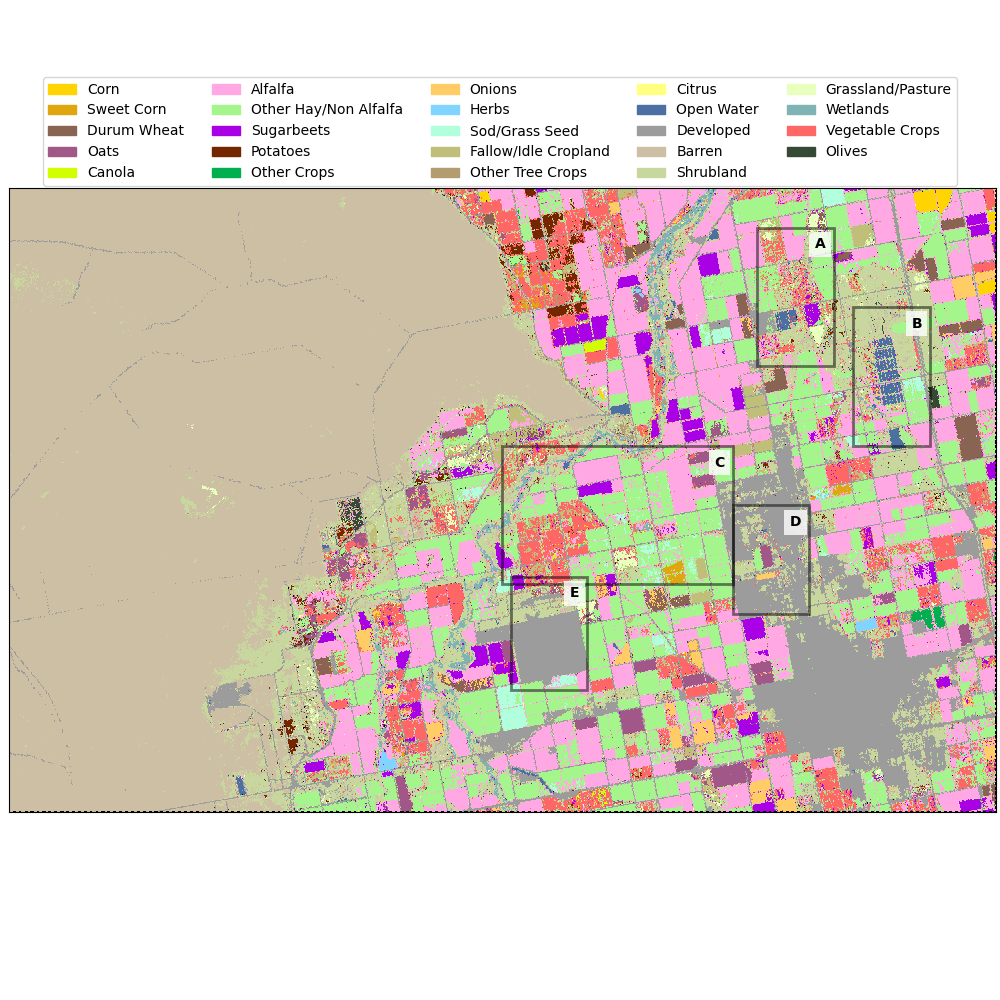

In [ ]:
fig, ax = plt.subplots(figsize=(10,10),constrained_layout=True)   #need to change aspect ratio to reflect true aspect ratio
plt.imshow(np.fliplr(remapped),aspect=aspect_rat,interpolation = 'none',cmap=usda_cmap_2)
# add focus areas
ax.add_patch(imp_roads_rect)
ax.add_patch(tsct_roads_rect)
ax.add_patch(el_airport_rect)
ax.add_patch(pools_rect)
ax.add_patch(imp_airport_rect)
ax.text(imperial_road[2]-75,imperial_road[1]+25,'A',fontsize=10,fontweight='bold',ha='right',va='top', \
         bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(pools[2]-75,pools[1]+25,'B',fontsize=10,fontweight='bold',ha='right',va='top', \
         bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(transect_roads[2]-75,transect_roads[1]+25,'C',fontsize=10,fontweight='bold',ha='right',va='top', \
         bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(imperial_airport[2]-75,imperial_airport[1]+25,'D',fontsize=10,fontweight='bold',ha='right',va='top', \
         bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(ElCentro_airport[2]-75,ElCentro_airport[1]+25,'E',fontsize=10,fontweight='bold',ha='right',va='top', \
         bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax.set_xticks([]); ax.set_yticks([])

# Legend
legend_patches = []
for cls in classes_to_plot:
    color = cdl_hex[cls]
    if cls == 0:
        label = "Background"
    else:
        label = f"{cls}: {value_to_crop.get(cls, f'Class {cls}')}"
    legend_patches.append(patches.Patch(color=color, label=label))

fig.legend(handles=legend_handles, bbox_to_anchor=(0.5,0.93), ncols=5, loc='upper center')
plt.show()
#plt.savefig('crop_map.png',transparent=True,bbox_inches='tight',dpi=500)

In [14]:
# # load average coherence (average gamma1 and average gamma2)
saveDir_avg = '../../2_Calculating_coherence_2_ways/'

fileNameAvg_1 = 'avg_coh_method1.r4'  
f1 = gdal.Open(saveDir_avg + fileNameAvg_1, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m1 = f1.ReadAsArray()
f1 = None

fileNameAvg_2 = 'avg_coh_method2.r4'  
f2 = gdal.Open(saveDir_avg + fileNameAvg_2, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m2 = f2.ReadAsArray()
f2 = None

#calculate differences between method 1 and method 2
capped_m2 = np.where(coh_avg_m2 > 0.8475, 0.8475, coh_avg_m2)
diff_avg = coh_avg_m1 - capped_m2
diff = coh_avg_m1 - coh_avg_m2

In [15]:
# make a function for adding a colorbar because it's VERY finicky
def add_colorbar(fig, ax, im, side="left", width=0.025, pad=0.00, height=0.2, label=None, visible=True):
    pos = ax.get_position()
    y0 = pos.y0 + (pos.height - height) / 2
    if side == "left":
        cax = fig.add_axes([
            pos.x0 - pad - width,
            y0,
            width,
            height
        ])
        orientation = "vertical"
        tick_side = "left"
        label_side = "left"
    else:
        cax = fig.add_axes([
            pos.x1 + pad,
            y0,
            width,
            height
        ])
        orientation = "vertical"
        tick_side = "right"
        label_side = "right"
    cbar = fig.colorbar(im, cax=cax, orientation=orientation)
    # ---- THIS is the important part ----
    if side == "left":
        cbar.ax.yaxis.set_ticks_position('left')
        cbar.ax.yaxis.set_label_position('left')
    else:
        cbar.ax.yaxis.set_ticks_position('right')
        cbar.ax.yaxis.set_label_position('right')
    if label:
        cbar.set_label(label)

    if visible==False:
        cbar.ax.set_visible(False)
    return cbar

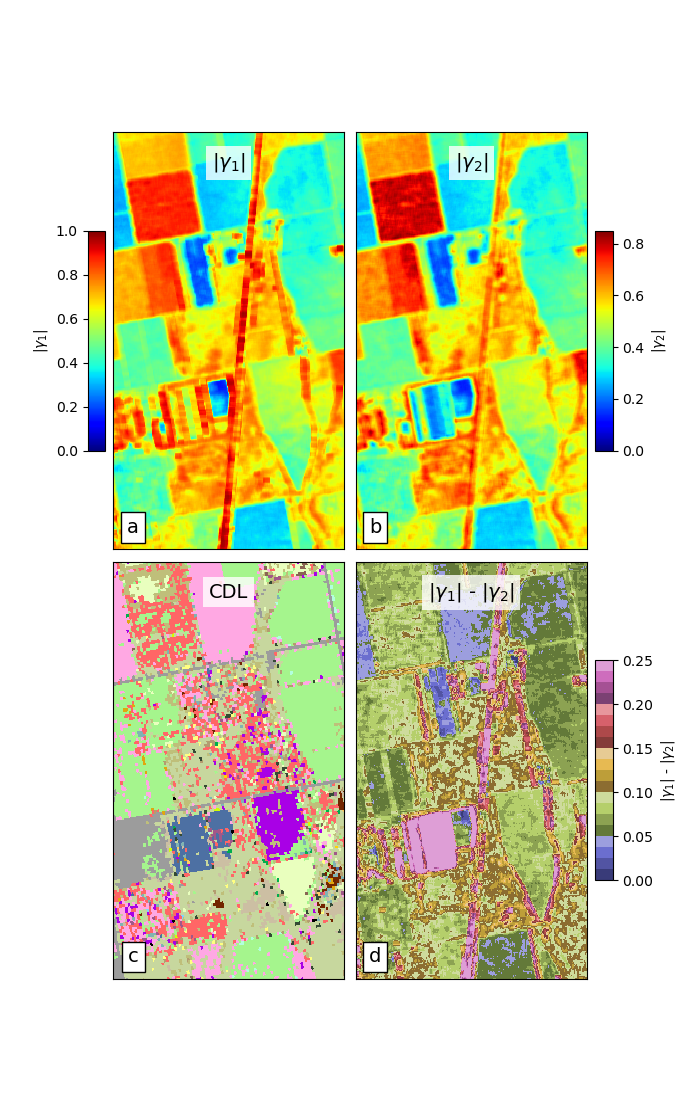

In [ ]:
# This is focus region A 
zoom_in = imperial_road
loc_of_xy_center = zoom_in[2]-(zoom_in[2]-zoom_in[0])/2

label_x = 0.11
label_y = 0.03
props = dict(boxstyle='square',facecolor='white',edgecolor='black')
frac = 0.025

fig, axs = plt.subplots(2,2,figsize=(7,11)) # figsize just has to be big enough to accomodate the aspect ratio!!!
plt.subplots_adjust(wspace=0.05,hspace=0.03,left=0.15,right=0.85)

ax = axs[0,0]
im = ax.imshow(np.fliplr(coh_avg_m1),interpolation ='none',cmap='jet',vmin=0,vmax=1)
ax.set_anchor('E')
ax.set_aspect(aspect_rat)
add_colorbar(fig,ax,im,side='left',label='$|\\gamma_{1}|$')
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+30,'|$\gamma_{1}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[0,1]
im = ax.imshow(np.fliplr(coh_avg_m2),interpolation ='none',cmap='jet',vmin=0,vmax=0.85)
ax.set_aspect(aspect_rat)
ax.set_anchor('W')
add_colorbar(fig,ax,im,side='right',label='$|\\gamma_{2}|$')
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+30,'|$\gamma_{2}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[1,0]
im = ax.imshow(np.fliplr(remapped),interpolation ='none',cmap=usda_cmap_2)
ax.set_aspect(aspect_rat)
ax.set_anchor('E')
add_colorbar(fig,ax,im,side='left',label='crop',visible=False)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'c', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+30,'CDL',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[1,1]
im = ax.imshow(np.fliplr(diff_avg),interpolation ='none',cmap='tab20b',vmin=0,vmax=0.25)
ax.set_aspect(aspect_rat)
ax.set_anchor('W')
add_colorbar(fig,ax,im,side='right',label='$|\gamma_{1}|$ - $|\gamma_{2}|$')
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'd', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+30,'|$\gamma_{1}$| - |$\gamma_{2}$|',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

plt.show()
# plt.savefig('focus_area_A_imperial_road.png', transparent=True, bbox_inches='tight',dpi=500)

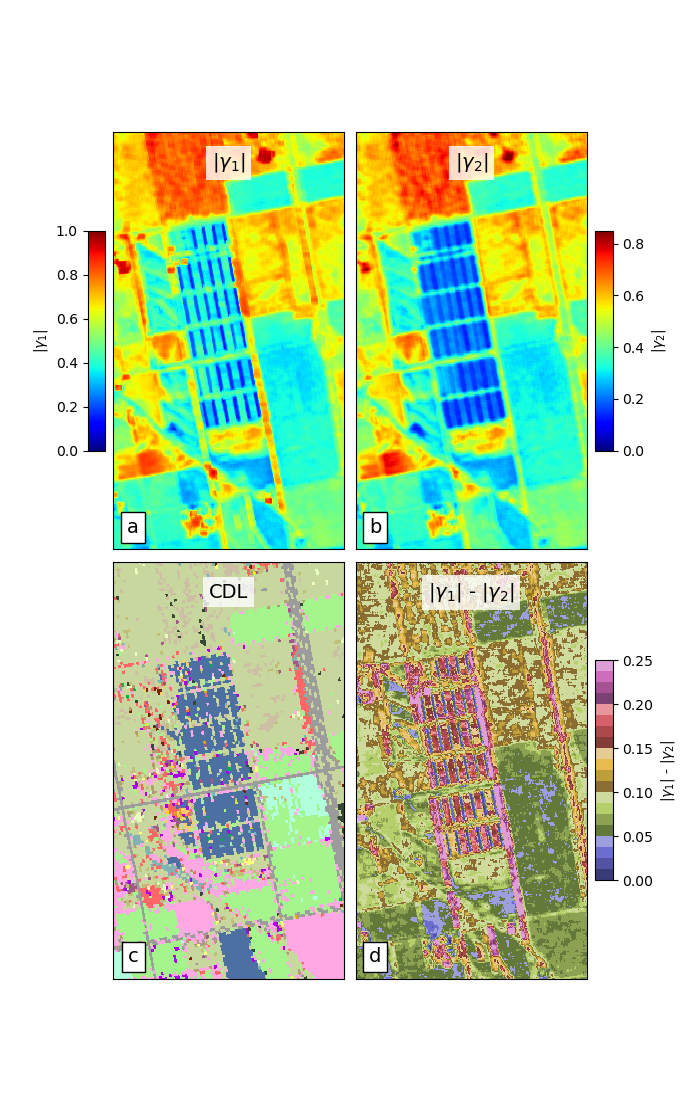

In [ ]:
# This is focus region B 
zoom_in = pools
loc_of_xy_center = zoom_in[2]-(zoom_in[2]-zoom_in[0])/2

label_x = 0.11
label_y = 0.03
props = dict(boxstyle='square',facecolor='white',edgecolor='black')
frac = 0.025

fig, axs = plt.subplots(2,2,figsize=(7,11)) # figsize just has to be big enough to accomodate the aspect ratio!!!
plt.subplots_adjust(wspace=0.05,hspace=0.03,left=0.15,right=0.85)

ax = axs[0,0]
im = ax.imshow(np.fliplr(coh_avg_m1),interpolation ='none',cmap='jet',vmin=0,vmax=1)
ax.set_anchor('E')
ax.set_aspect(aspect_rat)
add_colorbar(fig,ax,im,side='left',label='$|\\gamma_{1}|$')
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+30,'|$\gamma_{1}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[0,1]
im = ax.imshow(np.fliplr(coh_avg_m2),interpolation ='none',cmap='jet',vmin=0,vmax=0.85)
ax.set_aspect(aspect_rat)
ax.set_anchor('W')
add_colorbar(fig,ax,im,side='right',label='$|\\gamma_{2}|$')
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+30,'|$\gamma_{2}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[1,0]
im = ax.imshow(np.fliplr(remapped),interpolation ='none',cmap=usda_cmap_2)
ax.set_aspect(aspect_rat)
ax.set_anchor('E')
add_colorbar(fig,ax,im,side='left',label='crop',visible=False)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'c', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+30,'CDL',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[1,1]
im = ax.imshow(np.fliplr(diff_avg),interpolation ='none',cmap='tab20b',vmin=0,vmax=0.25)
ax.set_aspect(aspect_rat)
ax.set_anchor('W')
add_colorbar(fig,ax,im,side='right',label='$|\gamma_{1}|$ - $|\gamma_{2}|$')
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'd', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+30,'|$\gamma_{1}$| - |$\gamma_{2}$|',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

plt.show()
# plt.savefig('focus_area_B_pools.png', transparent=True, bbox_inches='tight',dpi=500)

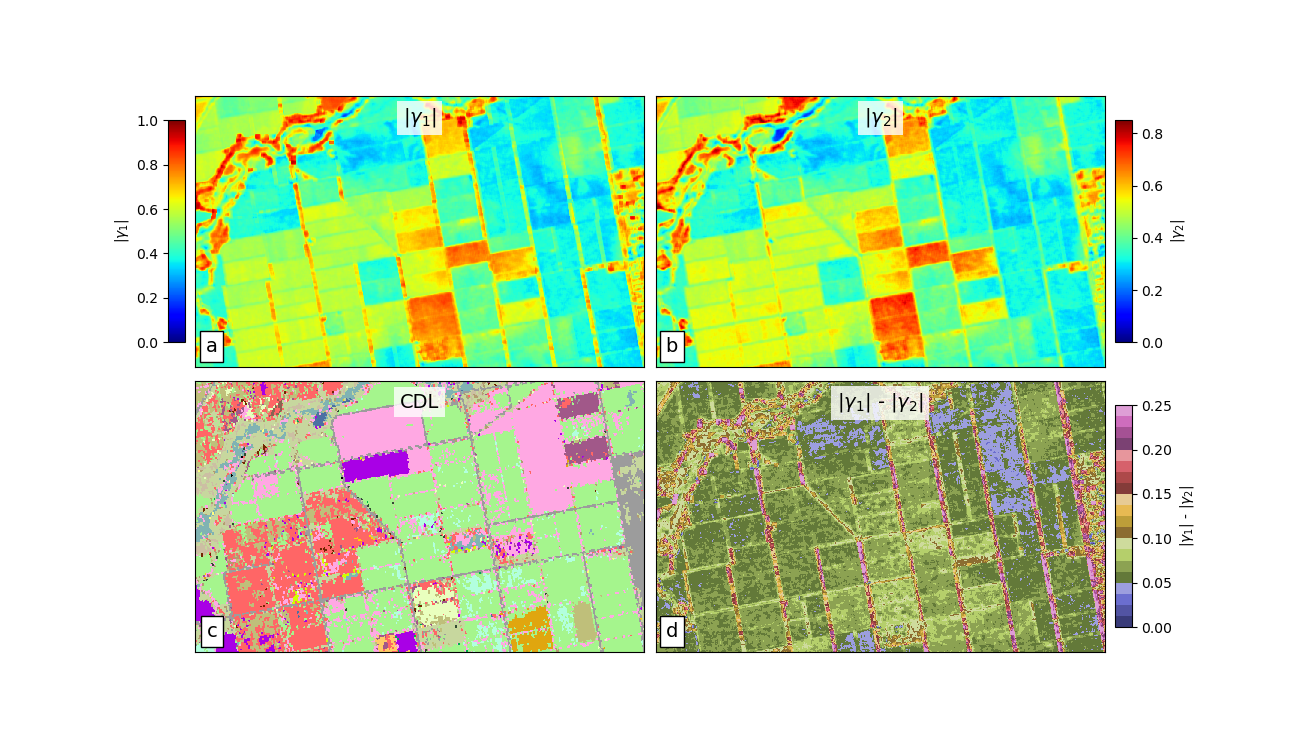

In [ ]:
# This is focus region C
zoom_in = transect_roads
loc_of_xy_center = zoom_in[2]-(zoom_in[2]-zoom_in[0])/2

label_x = 0.05
label_y = 0.04
props = dict(boxstyle='square',facecolor='white',edgecolor='black')
frac = 0.025

fig, axs = plt.subplots(2,2,figsize=(13,7.4)) # figsize just has to be big enough to accomodate the aspect ratio!!!
plt.subplots_adjust(wspace=0.025,hspace=0.00,left=0.15,right=0.85)

ax = axs[0,0]
im = ax.imshow(np.fliplr(coh_avg_m1),interpolation ='none',cmap='jet',vmin=0,vmax=1)
ax.set_anchor('E')
ax.set_aspect(aspect_rat)
add_colorbar(fig,ax,im,side='left',label='$|\\gamma_{1}|$',width=0.013,pad=0.0075,height=0.3)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+35,'|$\gamma_{1}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[0,1]
im = ax.imshow(np.fliplr(coh_avg_m2),interpolation ='none',cmap='jet',vmin=0,vmax=0.85)
ax.set_aspect(aspect_rat)
ax.set_anchor('W')
add_colorbar(fig,ax,im,side='right',label='$|\\gamma_{2}|$',width=0.013,pad=0.0075,height=0.3)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+35,'|$\gamma_{2}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[1,0]
im = ax.imshow(np.fliplr(remapped),interpolation ='none',cmap=usda_cmap_2)
ax.set_aspect(aspect_rat)
ax.set_anchor('E')
add_colorbar(fig,ax,im,side='left',label='crop',visible=False,width=0.013,pad=0.0075,height=0.3)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'c', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+35,'CDL',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[1,1]
im = ax.imshow(np.fliplr(diff_avg),interpolation ='none',cmap='tab20b',vmin=0,vmax=0.25)
ax.set_aspect(aspect_rat)
ax.set_anchor('W')
add_colorbar(fig,ax,im,side='right',label='$|\gamma_{1}|$ - $|\gamma_{2}|$',width=0.013,pad=0.0075,height=0.3)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'd', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+35,'|$\gamma_{1}$| - |$\gamma_{2}$|',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

plt.show()
# plt.savefig('focus_area_C_transect_roads.png', transparent=True, bbox_inches='tight',dpi=500)

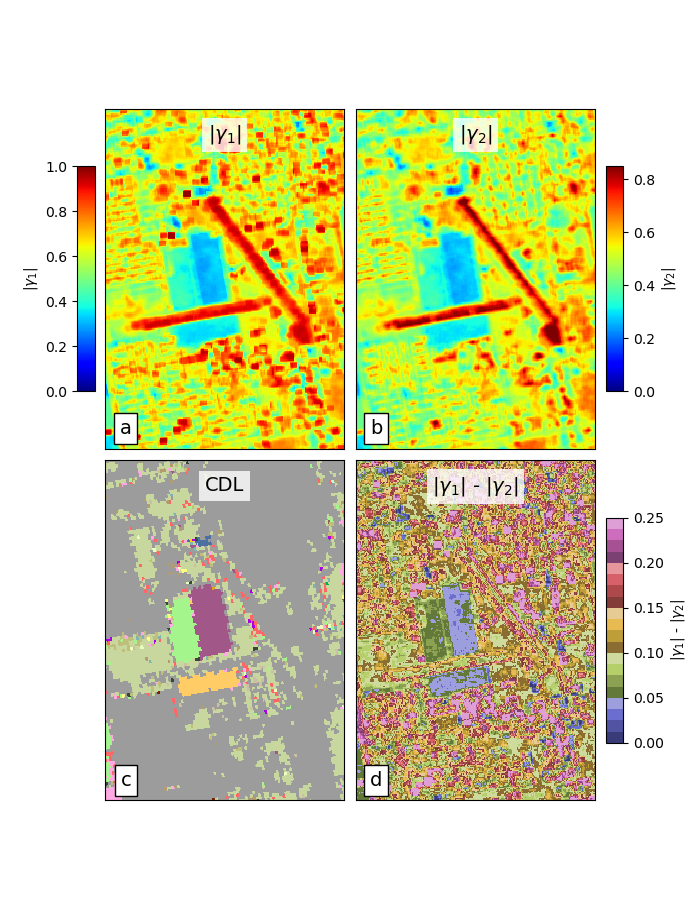

In [ ]:
# This is focus area D
zoom_in = imperial_airport
loc_of_xy_center = zoom_in[2]-(zoom_in[2]-zoom_in[0])/2

label_x = 0.11
label_y = 0.03
props = dict(boxstyle='square',facecolor='white',edgecolor='black')
frac = 0.025

fig, axs = plt.subplots(2,2,figsize=(7,9)) # figsize just has to be big enough to accomodate the aspect ratio!!!
plt.subplots_adjust(wspace=0.05,hspace=0.03,left=0.15,right=0.85)

ax = axs[0,0]
im = ax.imshow(np.fliplr(coh_avg_m1),interpolation ='none',cmap='jet',vmin=0,vmax=1)
ax.set_anchor('E')
ax.set_aspect(aspect_rat)
add_colorbar(fig,ax,im,side='left',label='$|\\gamma_{1}|$',pad=0.015,height=0.25)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+25,'|$\gamma_{1}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[0,1]
im = ax.imshow(np.fliplr(coh_avg_m2),interpolation ='none',cmap='jet',vmin=0,vmax=0.85)
ax.set_aspect(aspect_rat)
ax.set_anchor('W')
add_colorbar(fig,ax,im,side='right',label='$|\\gamma_{2}|$',pad=0.015,height=0.25)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+25,'|$\gamma_{2}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[1,0]
im = ax.imshow(np.fliplr(remapped),interpolation ='none',cmap=usda_cmap_2)
ax.set_aspect(aspect_rat)
ax.set_anchor('E')
add_colorbar(fig,ax,im,side='left',label='crop',visible=False,pad=0.015,height=0.25)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'c', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+25,'CDL',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[1,1]
im = ax.imshow(np.fliplr(diff_avg),interpolation ='none',cmap='tab20b',vmin=0,vmax=0.25)
ax.set_aspect(aspect_rat)
ax.set_anchor('W')
add_colorbar(fig,ax,im,side='right',label='$|\gamma_{1}|$ - $|\gamma_{2}|$',pad=0.015,height=0.25)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'd', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+25,'|$\gamma_{1}$| - |$\gamma_{2}$|',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

plt.show()
# plt.savefig('focus_area_D_imperial_airport.png', transparent=True, bbox_inches='tight',dpi=500)

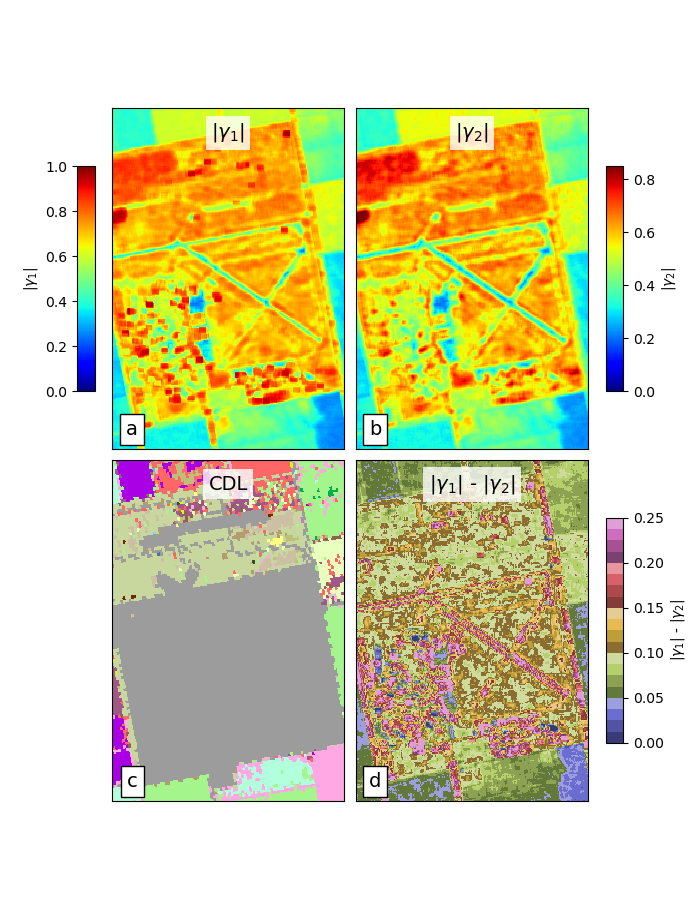

In [ ]:
#This is focus area E
zoom_in = ElCentro_airport
loc_of_xy_center = zoom_in[2]-(zoom_in[2]-zoom_in[0])/2

label_x = 0.11
label_y = 0.03
props = dict(boxstyle='square',facecolor='white',edgecolor='black')
frac = 0.025

fig, axs = plt.subplots(2,2,figsize=(7,9)) # figsize just has to be big enough to accomodate the aspect ratio!!!
plt.subplots_adjust(wspace=0.05,hspace=0.03,left=0.15,right=0.85)

ax = axs[0,0]
im = ax.imshow(np.fliplr(coh_avg_m1),interpolation ='none',cmap='jet',vmin=0,vmax=1)
ax.set_anchor('E')
ax.set_aspect(aspect_rat)
add_colorbar(fig,ax,im,side='left',label='$|\\gamma_{1}|$',pad=0.015,height=0.25)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+25,'|$\gamma_{1}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[0,1]
im = ax.imshow(np.fliplr(coh_avg_m2),interpolation ='none',cmap='jet',vmin=0,vmax=0.85)
ax.set_aspect(aspect_rat)
ax.set_anchor('W')
add_colorbar(fig,ax,im,side='right',label='$|\\gamma_{2}|$',pad=0.015,height=0.25)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+25,'|$\gamma_{2}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[1,0]
im = ax.imshow(np.fliplr(remapped),interpolation ='none',cmap=usda_cmap_2)
ax.set_aspect(aspect_rat)
ax.set_anchor('E')
add_colorbar(fig,ax,im,side='left',label='crop',visible=False,pad=0.015,height=0.25)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'c', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+25,'CDL',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[1,1]
im = ax.imshow(np.fliplr(diff_avg),interpolation ='none',cmap='tab20b',vmin=0,vmax=0.25)
ax.set_aspect(aspect_rat)
ax.set_anchor('W')
add_colorbar(fig,ax,im,side='right',label='$|\gamma_{1}|$ - $|\gamma_{2}|$',pad=0.015,height=0.25)
ax.set_xlim(zoom_in[0], zoom_in[2])
ax.set_ylim(zoom_in[3], zoom_in[1])
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'd', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,zoom_in[1]+25,'|$\gamma_{1}$| - |$\gamma_{2}$|',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

plt.show()
# plt.savefig('focus_area_E_ElCentro_airport.png', transparent=True, bbox_inches='tight',dpi=500)